# Entities & Networks (build at least from STRICT)
Works (CSV)
ALL with enrichment fields (in_scopus_flag, scopus_type, sjr_quartile, sjr_value,
h_index_scimago, plus EU/collab flags).
STRICT subset (Scopus-indexed; optional SJR threshold).
## Institutions
For each institution observed in the chosen layer:
institution_id, institution_name, country_code, type (OpenAlex or name heuristic),
works_count, citations_sum, oa_share, collaboration_rate (share of multi-institution
papers), multi_country_rate,
top_5_concepts (with counts), top_5_sources/journals, and publications by year since 2020.

In [1]:
import ast
import pandas as pd


In [2]:

# strict is your STRICT dataframe already loaded from CSV, e.g.:
strict = pd.read_csv("openalex_works_strict_q1_q3.csv")

# 1) Helper: safely parse strings that look like JSON/lists/dicts
def safe_parse_json(x):
    """
    If x is a string starting with '[' or '{', try to parse it with ast.literal_eval.
    Otherwise return x unchanged.
    """
    if isinstance(x, str):                      # only care about strings
        s = x.strip()                           # remove spaces at start/end
        if s and s[0] in "[{":                  # starts with [ or { -> likely list/dict
            try:
                return ast.literal_eval(s)      # turn string into real Python object
            except (SyntaxError, ValueError):   # if parsing fails -> keep original
                return x
    return x                                    # non-strings or other cases -> unchanged

# 2) List of columns that may contain JSON-like strings
json_like_cols = [
    "authorships",
    "concepts_parsed",
    "topics_parsed",
    "primary_location",
    "open_access"
]

# 3) Apply parser to each of these columns IF they exist
for col in json_like_cols:
    if col in strict.columns:
        strict[col] = strict[col].apply(safe_parse_json)


In [3]:
#print the name of allthe columns in the dataframe
print(strict.columns.tolist())

['id', 'doi', 'title', 'abstract_inverted_index', 'publication_year', 'publication_date', 'open_access', 'type', 'language', 'cited_by_count', 'primary_location', 'best_oa_location', 'primary_topic', 'topics', 'locations', 'concepts', 'authorships', 'referenced_works', 'countries_distinct_count', 'keywords', 'counts_by_year', 'has_eu_affiliation', 'has_multiple_institutions', 'distinct_institutions', 'has_multiple_countries', 'distinct_countries', 'topics_parsed', 'concepts_parsed', 'all_issns', 'issn_list', 'issn_norm_list', 'has_any_issn', 'num_issn', 'in_scopus_flag', 'scopus_type', 'sjr_quartile', 'sjr_value', 'h_index_scimago', 'keep_q1_q3_any', 'is_strict_in_scopus', 'is_strict_q1_q3']


Build long institutions from authors

In [4]:
inst_rows = []

for _, row in strict.iterrows():
    work_id = row["id"]
    authorships = row.get("authorships", [])

    if not isinstance(authorships, list):
        continue

    for auth in authorships:
        insts = auth.get("institutions", [])
        if not isinstance(insts, list):
            continue

        for inst in insts:
            inst_id   = inst.get("id")
            inst_name = inst.get("display_name")
            country   = inst.get("country_code")
            inst_type = inst.get("type")

            # fallback if id is missing
            if inst_id is None:
                inst_id = f"noid::{(inst_name or '').strip()}"

            if inst_type is None:
                inst_type = "unknown"

            inst_rows.append(
                (work_id, inst_id, inst_name, country, inst_type)
            )

inst_long = pd.DataFrame(
    inst_rows,
    columns=["work_id", "institution_id", "institution_name", "country_code", "inst_type"]
)

print("Institution long table shape:", inst_long.shape)


Institution long table shape: (29075, 5)


In [5]:
# Make a simple alias for work id
strict["work_id"] = strict["id"]   # e.g. 'https://openalex.org/W3156614709'

# ---------- extract 'is_oa' from open_access dict ----------

def extract_is_oa(x):
    """
    open_access column holds a dict like:
    {'is_oa': True, 'oa_status': 'gold', ...}
    We want a simple True/False flag.
    """
    # Case 1: already a dictionary
    if isinstance(x, dict):
        return bool(x.get("is_oa", False))  # return x['is_oa'] if exists, else False

    # Case 2: string that looks like a dict -> parse it
    if isinstance(x, str):
        try:
            d = ast.literal_eval(x)
            if isinstance(d, dict):
                return bool(d.get("is_oa", False))
        except Exception:
            return False

    # Anything else (NaN, None, weird types) -> treat as not OA
    return False

strict["is_oa"] = strict["open_access"].apply(extract_is_oa)

# ---------- extract source / journal name from primary_location ----------

def extract_source_name(pl):
    """
    primary_location often looks like:
      {'source': {'display_name': 'Complexity', ...}, ...}

    We want the journal name: 'Complexity'
    """
    # Case 1: already a dict
    if isinstance(pl, dict):
        src = pl.get("source") or {}          # get 'source' dict or empty
        if isinstance(src, dict):
            return src.get("display_name")    # journal name

    # Case 2: string that looks like a dict -> parse
    if isinstance(pl, str):
        try:
            d = ast.literal_eval(pl)
            if isinstance(d, dict):
                src = d.get("source") or {}
                if isinstance(src, dict):
                    return src.get("display_name")
        except Exception:
            return None

    # If nothing works, return None (missing)
    return None

strict["source_display_name"] = strict["primary_location"].apply(extract_source_name)


Explode institutions from authorships

In [6]:
inst_rows = []   # we'll collect tuples here: (work_id, inst_id, inst_name, country_code, inst_type)

for _, row in strict.iterrows():                    # loop through each paper (work)
    work_id = row["work_id"]                        # e.g. 'https://openalex.org/W3156614709'
    authorships = row.get("authorships", [])        # list of authors for this work

    if not isinstance(authorships, list):           # if still not a list -> skip this work
        continue

    for auth in authorships:                        # loop over each author
        insts = auth.get("institutions", [])        # list of institutions for this author

        if not isinstance(insts, list):             # safety check
            continue

        for inst in insts:                          # loop over each institution
            inst_id   = inst.get("id")              # institution identifier
            inst_name = inst.get("display_name")    # institution name (string)
            country   = inst.get("country_code")    # country code like 'CN', 'DE'
            inst_type = inst.get("type")            # type like 'education', 'facility'

            # If institution id is missing, create a fallback id based on name
            if inst_id is None:
                inst_id = f"noid::{(inst_name or '').strip()}"

            # If type is missing, mark as 'unknown'
            if inst_type is None:
                inst_type = "unknown"

            # Append a row (tuple) to our list
            inst_rows.append(
                (work_id, inst_id, inst_name, country, inst_type)
            )

# Turn list of tuples into a DataFrame with 1 row per (work, institution)
inst_long = pd.DataFrame(
    inst_rows,
    columns=["work_id", "institution_id", "institution_name", "country_code", "inst_type"]
)

print("Institution long table shape:", inst_long.shape)


Institution long table shape: (29075, 5)


Attach work-level metrics to each (work, institution)

Now we want for each row in inst_long to also know:

cited_by_count

is_oa

publication_year

source_display_name

has_multiple_institutions, has_multiple_countries

In [7]:
# columns we want to merge from strict (one per work)
work_cols = [
    "work_id",
    "cited_by_count",
    "is_oa",
    "publication_year",
    "source_display_name",
    "has_multiple_institutions",
    "has_multiple_countries",
    "concepts_parsed" 
]

# merge inst_long with these work-level columns on work_id
inst_core = inst_long.merge(
    strict[work_cols],
    on="work_id",
    how="left"
)

# clean up types
inst_core["cited_by_count"] = inst_core["cited_by_count"].fillna(0).astype(int)
inst_core["is_oa"] = inst_core["is_oa"].fillna(False).astype(bool)

# rename for easier understanding
inst_core["is_multi_inst"]    = inst_core["has_multiple_institutions"].fillna(False)
inst_core["is_multi_country"] = inst_core["has_multiple_countries"].fillna(False)


Aggregate to institution-level metrics

In [8]:
inst_agg = (
    inst_core
    .groupby(["institution_id", "institution_name", "country_code", "inst_type"], dropna=False)
    .agg(
        works_count        = ("work_id", "nunique"),   # number of distinct works
        citations_sum      = ("cited_by_count", "sum"),
        oa_share           = ("is_oa", "mean"),        # share of works that are OA
        collaboration_rate = ("is_multi_inst", "mean"),# share of works with multiple institutions
        multi_country_rate = ("is_multi_country", "mean")
    )
    .reset_index()
)


## Top 5 concepts per institution

helper to extract concepts 

In [9]:


# 1) Helper: extract clean list of concept names from concepts_parsed
def extract_concept_names(concepts_cell):
    """
    Input: one cell from inst_core['concepts_parsed'].
    Possible cases:
      - list of dicts, e.g. [{'display_name': 'Learning analytics', ...}, ...]
      - single dict: {'display_name': 'Learning analytics', ...}
      - string representation of the above
      - NaN / None
    Output:
      - list of strings, e.g. ['Learning analytics', 'Educational data mining']
    """

    # Case 0: explicit None
    if concepts_cell is None:
        return []

    # Case 1: float NaN (typical pandas missing)
    if isinstance(concepts_cell, float):
        # check if it's NaN
        if pd.isna(concepts_cell):
            return []

    # Case 2: already a list (most common)
    if isinstance(concepts_cell, list):
        names = []
        for item in concepts_cell:
            # typical case: dict with 'display_name'
            if isinstance(item, dict):
                name = item.get("display_name")
                if name:
                    names.append(str(name))
            else:
                # if it's something else (string, etc.) -> just convert to string
                names.append(str(item))
        return names

    # Case 3: single dict
    if isinstance(concepts_cell, dict):
        name = concepts_cell.get("display_name")
        return [str(name)] if name else []

    # Case 4: string -> try to parse with literal_eval
    if isinstance(concepts_cell, str):
        s = concepts_cell.strip()
        if s == "":
            return []
        try:
            parsed = ast.literal_eval(s)
            # Recursively call the same function on parsed object
            return extract_concept_names(parsed)
        except Exception:
            # if parsing fails, treat whole string as one "concept name"
            return [s]

    # Case 5: any other weird type
    try:
        if pd.isna(concepts_cell):
            return []
    except Exception:
        pass

    # Fallback: just cast to string
    return [str(concepts_cell)]


# 2) Quick preview: apply to first few rows to see what comes out
print("Preview of extracted concept names for first 5 rows in inst_core:")
for i in range(5):
    raw_cell = inst_core["concepts_parsed"].iloc[i]
    print(f"Row {i}:")
    print("  raw:", raw_cell)
    print("  extracted:", extract_concept_names(raw_cell))
    print("-" * 50)


Preview of extracted concept names for first 5 rows in inst_core:
Row 0:
  raw: [{'display_name': 'Curriculum', 'level': 2, 'score': 0.5452895164489746}, {'display_name': 'Computer science', 'level': 0, 'score': 0.5172855854034424}, {'display_name': 'Field (mathematics)', 'level': 2, 'score': 0.46225565671920776}, {'display_name': 'Engineering ethics', 'level': 1, 'score': 0.4140339493751526}, {'display_name': 'Knowledge management', 'level': 1, 'score': 0.336037814617157}, {'display_name': 'Management science', 'level': 1, 'score': 0.3205817937850952}, {'display_name': 'Psychology', 'level': 0, 'score': 0.27662089467048645}, {'display_name': 'Pedagogy', 'level': 1, 'score': 0.22286361455917358}, {'display_name': 'Engineering', 'level': 0, 'score': 0.12583649158477783}, {'display_name': 'Pure mathematics', 'level': 1, 'score': 0.0}, {'display_name': 'Mathematics', 'level': 0, 'score': 0.0}]
  extracted: ['Curriculum', 'Computer science', 'Field (mathematics)', 'Engineering ethics', 'Kn

Build long table: (institution, concept_name)

| institution_id | institution_name | concept_name            |
| -------------- | ---------------- | ----------------------- |
| I123           | University of X  | Learning analytics      |
| I123           | University of X  | Educational data mining |
| I456           | University of Y  | Learning analytics      |


In [10]:
# 3) Build long table of (institution, concept_name)

concept_rows = []  # list of tuples: (institution_id, institution_name, concept_name)

for _, row in inst_core.iterrows():
    inst_id   = row["institution_id"]
    inst_name = row["institution_name"]
    cell      = row.get("concepts_parsed")

    # use our helper to get a list of strings
    concept_list = extract_concept_names(cell)

    # for each concept in this paper for this institution, add a row
    for cname in concept_list:
        concept_rows.append((inst_id, inst_name, cname))

# turn the list into a DataFrame
inst_concepts_long = pd.DataFrame(
    concept_rows,
    columns=["institution_id", "institution_name", "concept_name"]
)

print("Long concepts table shape:", inst_concepts_long.shape)
print("\nPreview of inst_concepts_long:")
print(inst_concepts_long.head(10))


Long concepts table shape: (403108, 3)

Preview of inst_concepts_long:
                   institution_id                institution_name  \
0  https://openalex.org/I62916508  Technical University of Munich   
1  https://openalex.org/I62916508  Technical University of Munich   
2  https://openalex.org/I62916508  Technical University of Munich   
3  https://openalex.org/I62916508  Technical University of Munich   
4  https://openalex.org/I62916508  Technical University of Munich   
5  https://openalex.org/I62916508  Technical University of Munich   
6  https://openalex.org/I62916508  Technical University of Munich   
7  https://openalex.org/I62916508  Technical University of Munich   
8  https://openalex.org/I62916508  Technical University of Munich   
9  https://openalex.org/I62916508  Technical University of Munich   

           concept_name  
0            Curriculum  
1      Computer science  
2   Field (mathematics)  
3    Engineering ethics  
4  Knowledge management  
5    Manageme

Count concepts per institution

| institution_id | institution_name | concept_name       | concept_count |
| -------------- | ---------------- | ------------------ | ------------- |
| I123           | University of X  | learning analytics | 2             |
| I123           | University of X  | AI in education    | 1             |
| I456           | University of Y  | learning analytics | 3             |


.groupby(...).size() counts the number of rows in each group.

One group = one unique triple (institution_id, institution_name, concept_name).

So concept_count = how many papers from that institution have that concept.

In [11]:
# 4) Count how many times each concept appears per institution

inst_concepts_counts = (
    inst_concepts_long
    .groupby(["institution_id", "institution_name", "concept_name"])
    .size()
    .reset_index(name="concept_count")
)

print("Concept counts shape:", inst_concepts_counts.shape)
print("\nPreview of inst_concepts_counts:")
print(inst_concepts_counts.head(10))


Concept counts shape: (125002, 4)

Preview of inst_concepts_counts:
                    institution_id          institution_name  \
0  https://openalex.org/I100005738  Brigham Young University   
1  https://openalex.org/I100005738  Brigham Young University   
2  https://openalex.org/I100005738  Brigham Young University   
3  https://openalex.org/I100005738  Brigham Young University   
4  https://openalex.org/I100005738  Brigham Young University   
5  https://openalex.org/I100005738  Brigham Young University   
6  https://openalex.org/I100005738  Brigham Young University   
7  https://openalex.org/I100005738  Brigham Young University   
8  https://openalex.org/I100005738  Brigham Young University   
9  https://openalex.org/I100005738  Brigham Young University   

              concept_name  concept_count  
0     Academic achievement              1  
1               Aesthetics              1  
2                Analytics              1  
3                Animation              2  
4      

Build top_5_concepts string per institution

Group inst_concepts_counts by (institution_id, institution_name)

Sort concepts by concept_count (descending)

Take top 5

Pack into one string

In [12]:
# 5) For each institution, keep top 5 concepts and pack into a string

def pack_top_5_concepts(group):
    """
    group: subset of inst_concepts_counts for one institution.
    We sort concepts by concept_count (descending),
    take up to 5, and create a string:
      'Learning analytics (7); Educational data mining (4)'
    """
    # sort by concept_count, most frequent first
    top = group.sort_values("concept_count", ascending=False).head(5)

    parts = []
    for _, row in top.iterrows():
        cname = row["concept_name"]
        cnt   = row["concept_count"]
        parts.append(f"{cname} ({cnt})")

    # join with '; ' to one string
    return "; ".join(parts)

inst_top_concepts = (
    inst_concepts_counts
    .groupby(["institution_id", "institution_name"], as_index=False)
    .apply(pack_top_5_concepts)
    .rename(columns={None: "top_5_concepts"})
)

print("Top concepts table shape:", inst_top_concepts.shape)
print("\nPreview of inst_top_concepts:")
print(inst_top_concepts.head(10))


Top concepts table shape: (3606, 3)

Preview of inst_top_concepts:
                    institution_id                        institution_name  \
0  https://openalex.org/I100005738                Brigham Young University   
1  https://openalex.org/I100066346                 University of Stuttgart   
2  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
3  https://openalex.org/I100445878                École Centrale de Nantes   
4  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
5  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
6  https://openalex.org/I100930933               University College Dublin   
7  https://openalex.org/I101202996                   Semmelweis University   
8  https://openalex.org/I101407740                   Chandigarh University   
9  https://openalex.org/I102064193                     University of Siena   

                                      top_5_concepts  
0  Computer science

C:\Users\hamza\AppData\Local\Temp\ipykernel_27816\2589795338.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pack_top_5_concepts)


Merge top_5_concepts into your main institution table

In [13]:
# 6) Merge top_5_concepts into inst_agg

institutions_with_concepts = inst_agg.merge(
    inst_top_concepts,
    on=["institution_id", "institution_name"],
    how="left"
)

# if some institutions have no concepts (unlikely but possible), fill with empty string
institutions_with_concepts["top_5_concepts"] = institutions_with_concepts["top_5_concepts"].fillna("")

print("Institutions table with concepts shape:", institutions_with_concepts.shape)
print("\nPreview of institutions_with_concepts:")
print(institutions_with_concepts.head(10))


Institutions table with concepts shape: (3676, 10)

Preview of institutions_with_concepts:
                    institution_id                        institution_name  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   
5  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
6  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
7  https://openalex.org/I100930933               University College Dublin   
8  https://openalex.org/I101202996                   Semmelweis University   
9  https://openalex.org/I101407740                   Chandigarh University   

  country_code  inst_type  works_count  citations_

Merge top_5_concepts into your main institution table

In [14]:
# 6) Merge top_5_concepts into inst_agg

institutions_with_concepts = inst_agg.merge(
    inst_top_concepts,
    on=["institution_id", "institution_name"],
    how="left"
)

# if some institutions have no concepts (unlikely but possible), fill with empty string
institutions_with_concepts["top_5_concepts"] = institutions_with_concepts["top_5_concepts"].fillna("")

print("Institutions table with concepts shape:", institutions_with_concepts.shape)
print("\nPreview of institutions_with_concepts:")
print(institutions_with_concepts.head(10))


Institutions table with concepts shape: (3676, 10)

Preview of institutions_with_concepts:
                    institution_id                        institution_name  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   
5  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
6  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
7  https://openalex.org/I100930933               University College Dublin   
8  https://openalex.org/I101202996                   Semmelweis University   
9  https://openalex.org/I101407740                   Chandigarh University   

  country_code  inst_type  works_count  citations_

top_5_sources

Build long table: (institution, source_display_name)

In [15]:
# 1) Build long table of (institution, source_display_name)

# We only keep rows where source_display_name is not missing
src_long = (
    inst_core
    .dropna(subset=["source_display_name"])
    .loc[:, ["institution_id", "institution_name", "source_display_name"]]
)

print("src_long shape:", src_long.shape)
print("\nPreview of src_long:")
print(src_long.head(10))


src_long shape: (29075, 3)

Preview of src_long:
                   institution_id                        institution_name  \
0  https://openalex.org/I62916508          Technical University of Munich   
1  https://openalex.org/I62916508          Technical University of Munich   
2   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   
3  https://openalex.org/I62916508          Technical University of Munich   
4  https://openalex.org/I62916508          Technical University of Munich   
5   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   
6  https://openalex.org/I62916508          Technical University of Munich   
7  https://openalex.org/I62916508          Technical University of Munich   
8  https://openalex.org/I62916508          Technical University of Munich   
9   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   

                   source_display_name  
0  Learning and Individual Differences  
1  Learning and Indiv

Count how many works per (institution, source)

| institution_id | institution_name | source_display_name                  | source_count |
| -------------- | ---------------- | ------------------------------------ | ------------ |
| I123           | University of X  | Computers & Education                | 5            |
| I123           | University of X  | IJ of Artificial Intelligence in Edu | 3            |
| I456           | University of Y  | IEEE Transactions on Learning Tech   | 2            |


In [16]:
# 2) Count works per (institution, source_display_name)

inst_source_counts = (
    src_long
    .groupby(["institution_id", "institution_name", "source_display_name"])
    .size()
    .reset_index(name="source_count")
)

print("inst_source_counts shape:", inst_source_counts.shape)
print("\nPreview of inst_source_counts:")
print(inst_source_counts.head(10))


inst_source_counts shape: (11601, 4)

Preview of inst_source_counts:
                    institution_id          institution_name  \
0  https://openalex.org/I100005738  Brigham Young University   
1  https://openalex.org/I100005738  Brigham Young University   
2  https://openalex.org/I100005738  Brigham Young University   
3  https://openalex.org/I100005738  Brigham Young University   
4  https://openalex.org/I100005738  Brigham Young University   
5  https://openalex.org/I100005738  Brigham Young University   
6  https://openalex.org/I100066346   University of Stuttgart   
7  https://openalex.org/I100066346   University of Stuttgart   
8  https://openalex.org/I100066346   University of Stuttgart   
9  https://openalex.org/I100066346   University of Stuttgart   

                                 source_display_name  source_count  
0  International Journal of Educational Technolog...             1  
1  Journal of University Teaching and Learning Pr...             1  
2            Multim

Build top_5_sources string per institution

In [17]:
# 3) For each institution, keep top 5 sources and pack into a string

def pack_top_5_sources(group):
    """
    group: all rows (sources) for one institution.
    We sort by source_count (descending),
    take up to 5, and format like:
      'Computers & Education (5); IJAIED (3)'
    """
    top = group.sort_values("source_count", ascending=False).head(5)

    parts = []
    for _, row in top.iterrows():
        src_name = row["source_display_name"]
        cnt      = row["source_count"]
        parts.append(f"{src_name} ({cnt})")

    return "; ".join(parts)


inst_top_sources = (
    inst_source_counts
    .groupby(["institution_id", "institution_name"], as_index=False)
    .apply(pack_top_5_sources)
    .rename(columns={None: "top_5_sources"})
)

print("inst_top_sources shape:", inst_top_sources.shape)
print("\nPreview of inst_top_sources:")
print(inst_top_sources.head(10))


inst_top_sources shape: (3646, 3)

Preview of inst_top_sources:
                    institution_id                        institution_name  \
0  https://openalex.org/I100005738                Brigham Young University   
1  https://openalex.org/I100066346                 University of Stuttgart   
2  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
3  https://openalex.org/I100445878                École Centrale de Nantes   
4  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
5  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
6  https://openalex.org/I100930933               University College Dublin   
7  https://openalex.org/I101202996                   Semmelweis University   
8  https://openalex.org/I101407740                   Chandigarh University   
9  https://openalex.org/I102064193                     University of Siena   

                                       top_5_sources  
0  Multimodal Technolo

C:\Users\hamza\AppData\Local\Temp\ipykernel_27816\1192425510.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pack_top_5_sources)


Merge top_5_sources into your institution table

In [18]:
# 4) Merge top_5_sources into institutions_with_concepts

institutions_with_sources = institutions_with_concepts.merge(
    inst_top_sources,
    on=["institution_id", "institution_name"],
    how="left"
)

# If some institutions have no sources (very rare), fill with empty string
institutions_with_sources["top_5_sources"] = institutions_with_sources["top_5_sources"].fillna("")

print("institutions_with_sources shape:", institutions_with_sources.shape)
print("\nPreview of institutions_with_sources:")
print(institutions_with_sources.head(10))


institutions_with_sources shape: (3676, 11)

Preview of institutions_with_sources:
                    institution_id                        institution_name  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   
5  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
6  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
7  https://openalex.org/I100930933               University College Dublin   
8  https://openalex.org/I101202996                   Semmelweis University   
9  https://openalex.org/I101407740                   Chandigarh University   

  country_code  inst_type  works_count  citations_sum  oa_

## Publications by year

Filter to valid years ≥ 2020

In [19]:
# 1) Keep only rows with a valid publication_year >= 2020

inst_years = inst_core.dropna(subset=["publication_year"]).copy()

# publication_year might be float, so make it int for safety
inst_years["publication_year"] = inst_years["publication_year"].astype(int)

# filter to 2020+
inst_years = inst_years[inst_years["publication_year"] >= 2020]

print("inst_years shape:", inst_years.shape)
print("\nPreview of inst_years (first 10 rows):")
print(inst_years[["institution_id", "institution_name", "publication_year", "work_id"]].head(10))


inst_years shape: (29075, 14)

Preview of inst_years (first 10 rows):
                   institution_id                        institution_name  \
0  https://openalex.org/I62916508          Technical University of Munich   
1  https://openalex.org/I62916508          Technical University of Munich   
2   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   
3  https://openalex.org/I62916508          Technical University of Munich   
4  https://openalex.org/I62916508          Technical University of Munich   
5   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   
6  https://openalex.org/I62916508          Technical University of Munich   
7  https://openalex.org/I62916508          Technical University of Munich   
8  https://openalex.org/I62916508          Technical University of Munich   
9   https://openalex.org/I8204097  Ludwig-Maximilians-Universität München   

   publication_year                           work_id  
0              2023  https

Count works per (institution, year)

In [20]:
# 2) Count distinct works per (institution, year)

inst_year_counts = (
    inst_years
    .groupby(["institution_id", "institution_name", "publication_year"])
    ["work_id"]
    .nunique()
    .reset_index(name="works_count_year")
)

print("inst_year_counts shape:", inst_year_counts.shape)
print("\nPreview of inst_year_counts (first 10 rows):")
print(inst_year_counts.head(10))


inst_year_counts shape: (6871, 4)

Preview of inst_year_counts (first 10 rows):
                    institution_id                        institution_name  \
0  https://openalex.org/I100005738                Brigham Young University   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100005738                Brigham Young University   
3  https://openalex.org/I100005738                Brigham Young University   
4  https://openalex.org/I100005738                Brigham Young University   
5  https://openalex.org/I100066346                 University of Stuttgart   
6  https://openalex.org/I100066346                 University of Stuttgart   
7  https://openalex.org/I100066346                 University of Stuttgart   
8  https://openalex.org/I100066346                 University of Stuttgart   
9  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   

   publication_year  works_count_year  
0              2020  

Pack per-institution years into one string

In [21]:
# 3) For each institution, package publications by year into a string

def pack_pubs_by_year(group):
    """
    group: all rows for one institution across publication years.

    We build a dict {year: count}, then turn it into a
    string like: '2020: 3; 2021: 5; 2022: 2' (sorted by year).
    """
    # build dictionary year -> works_count_year
    year_map = {
        int(row.publication_year): int(row.works_count_year)
        for _, row in group.iterrows()
    }

    # make a sorted list of "YYYY: count" strings
    parts = [
        f"{year}: {count}"
        for year, count in sorted(year_map.items())
    ]

    return "; ".join(parts)


inst_pubs_by_year = (
    inst_year_counts
    .groupby(["institution_id", "institution_name"], as_index=False)
    .apply(pack_pubs_by_year)
    .rename(columns={None: "publications_by_year"})
)

print("inst_pubs_by_year shape:", inst_pubs_by_year.shape)
print("\nPreview of inst_pubs_by_year:")
print(inst_pubs_by_year.head(10))


inst_pubs_by_year shape: (3646, 3)

Preview of inst_pubs_by_year:
                    institution_id                        institution_name  \
0  https://openalex.org/I100005738                Brigham Young University   
1  https://openalex.org/I100066346                 University of Stuttgart   
2  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
3  https://openalex.org/I100445878                École Centrale de Nantes   
4  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
5  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
6  https://openalex.org/I100930933               University College Dublin   
7  https://openalex.org/I101202996                   Semmelweis University   
8  https://openalex.org/I101407740                   Chandigarh University   
9  https://openalex.org/I102064193                     University of Siena   

                                publications_by_year  
0        2020: 1; 20

C:\Users\hamza\AppData\Local\Temp\ipykernel_27816\3589075383.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pack_pubs_by_year)


Merge into your institution table

In [22]:
# 4) Merge publications_by_year into institutions_with_sources

institutions_full = institutions_with_sources.merge(
    inst_pubs_by_year,
    on=["institution_id", "institution_name"],
    how="left"
)

# If some institutions somehow have no works >= 2020 (shouldn't happen, but safe)
institutions_full["publications_by_year"] = institutions_full["publications_by_year"].fillna("")

print("institutions_full shape:", institutions_full.shape)
print("\nPreview of institutions_full (first 10 rows):")
print(institutions_full.head(10))


institutions_full shape: (3676, 12)

Preview of institutions_full (first 10 rows):
                    institution_id                        institution_name  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   
5  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
6  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
7  https://openalex.org/I100930933               University College Dublin   
8  https://openalex.org/I101202996                   Semmelweis University   
9  https://openalex.org/I101407740                   Chandigarh University   

  country_code  inst_type  works_count  citations_sum  oa_

In [23]:
institutions_full.to_csv("institutions_full_strict_q1_q3.csv", index=False)


Make sure authorships is parsed & work_id exists

In [24]:


# 0.1 Helper to safely parse JSON-like strings
def safe_parse_json(x):
    """
    If x is a string starting with '[' or '{', try to parse it with ast.literal_eval.
    Otherwise return x unchanged.
    """
    if isinstance(x, str):
        s = x.strip()
        if s and s[0] in "[{":
            try:
                return ast.literal_eval(s)
            except (SyntaxError, ValueError):
                return x
    return x

# 0.2 Parse JSON-like columns in strict
json_like_cols = [
    "authorships",
    "concepts_parsed",
    "topics_parsed",
    "primary_location",
    "open_access"
]

for col in json_like_cols:
    if col in strict.columns:
        strict[col] = strict[col].apply(safe_parse_json)

# 0.3 Ensure work_id exists
strict["work_id"] = strict["id"]

print("strict shape:", strict.shape)
print("Columns check:", [c for c in strict.columns if c in ["work_id", "authorships", "concepts_parsed"]])


strict shape: (5064, 44)
Columns check: ['authorships', 'concepts_parsed', 'work_id']


Build author_long: one row = (work, author)

In [25]:
# 1) Build long author table from authorships

author_rows = []  # list of tuples: (work_id, author_id, author_name, orcid)

for _, row in strict.iterrows():
    work_id     = row["work_id"]
    authorships = row.get("authorships", [])

    if not isinstance(authorships, list):
        # if something went wrong and it's not a list, skip this work
        continue

    for auth in authorships:
        # typical OpenAlex structure: {'author': {...}, 'institutions': [...]}
        author_info = auth.get("author", {}) or {}

        author_id   = author_info.get("id")
        author_name = author_info.get("display_name")
        orcid       = author_info.get("orcid")

        # if author_id is missing, create a fallback
        if author_id is None:
            author_id = f"noid::{(author_name or '').strip()}"

        author_rows.append((work_id, author_id, author_name, orcid))

author_long = pd.DataFrame(
    author_rows,
    columns=["work_id", "author_id", "author_name", "orcid"]
)

print("author_long shape:", author_long.shape)
print("\nPreview of author_long:")
print(author_long.head(10))


author_long shape: (25671, 4)

Preview of author_long:
                            work_id                         author_id  \
0  https://openalex.org/W4323655724  https://openalex.org/A5008809634   
1  https://openalex.org/W4323655724  https://openalex.org/A5013346660   
2  https://openalex.org/W4323655724  https://openalex.org/A5050063899   
3  https://openalex.org/W4323655724  https://openalex.org/A5052257833   
4  https://openalex.org/W4323655724  https://openalex.org/A5043273387   
5  https://openalex.org/W4323655724  https://openalex.org/A5005995116   
6  https://openalex.org/W4323655724  https://openalex.org/A5052258450   
7  https://openalex.org/W4323655724  https://openalex.org/A5004398345   
8  https://openalex.org/W4323655724  https://openalex.org/A5074504351   
9  https://openalex.org/W4323655724  https://openalex.org/A5059439673   

         author_name                                  orcid  
0  Enkelejda Kasneci                                   None  
1     Kathrin Seß

Attach work-level metrics to authors → author_core

In [26]:
# 2.1 Ensure 'is_oa' exists on strict (if not already created)

def extract_is_oa(x):
    """
    open_access column: dict like {'is_oa': True, 'oa_status': 'gold', ...}
    We want a simple True/False.
    """
    if isinstance(x, dict):
        return bool(x.get("is_oa", False))

    if isinstance(x, str):
        try:
            d = ast.literal_eval(x)
            if isinstance(d, dict):
                return bool(d.get("is_oa", False))
        except Exception:
            return False

    return False

if "is_oa" not in strict.columns:
    strict["is_oa"] = strict["open_access"].apply(extract_is_oa)

# 2.2 Select work-level columns to merge into author_long
work_cols_for_authors = [
    "work_id",
    "cited_by_count",
    "is_oa",
    "publication_year",
    "has_multiple_institutions",
    "has_multiple_countries",
    "concepts_parsed"
]

author_core = author_long.merge(
    strict[work_cols_for_authors],
    on="work_id",
    how="left"
)

# Clean types a bit
author_core["cited_by_count"] = author_core["cited_by_count"].fillna(0).astype(int)
author_core["is_oa"] = author_core["is_oa"].fillna(False).astype(bool)
author_core["publication_year"] = author_core["publication_year"].fillna(0).astype(int)

author_core["is_multi_inst"]    = author_core["has_multiple_institutions"].fillna(False)
author_core["is_multi_country"] = author_core["has_multiple_countries"].fillna(False)

print("author_core shape:", author_core.shape)
print("\nPreview of author_core:")
print(author_core.head(10))


author_core shape: (25671, 12)

Preview of author_core:
                            work_id                         author_id  \
0  https://openalex.org/W4323655724  https://openalex.org/A5008809634   
1  https://openalex.org/W4323655724  https://openalex.org/A5013346660   
2  https://openalex.org/W4323655724  https://openalex.org/A5050063899   
3  https://openalex.org/W4323655724  https://openalex.org/A5052257833   
4  https://openalex.org/W4323655724  https://openalex.org/A5043273387   
5  https://openalex.org/W4323655724  https://openalex.org/A5005995116   
6  https://openalex.org/W4323655724  https://openalex.org/A5052258450   
7  https://openalex.org/W4323655724  https://openalex.org/A5004398345   
8  https://openalex.org/W4323655724  https://openalex.org/A5074504351   
9  https://openalex.org/W4323655724  https://openalex.org/A5059439673   

         author_name                                  orcid  cited_by_count  \
0  Enkelejda Kasneci                                   None  

Aggregate to author-level basics (author_agg)

In [27]:
# 3) Aggregate to author-level metrics

author_agg = (
    author_core
    .groupby(["author_id", "author_name", "orcid"], dropna=False)
    .agg(
        works_count           = ("work_id", "nunique"),
        citations_sum         = ("cited_by_count", "sum"),
        oa_share              = ("is_oa", "mean"),
        multi_institution_share = ("is_multi_inst", "mean"),
        multi_country_share     = ("is_multi_country", "mean")
    )
    .reset_index()
)

print("author_agg shape:", author_agg.shape)
print("\nPreview of author_agg:")
print(author_agg.head(10))


author_agg shape: (17741, 8)

Preview of author_agg:
                          author_id           author_name  \
0   https://openalex.org/A100168145      Bruno Hochhegger   
1  https://openalex.org/A1043128496         David Baneres   
2   https://openalex.org/A105690434     Natalia Kucirkova   
3  https://openalex.org/A1060563842      John Garofalakis   
4  https://openalex.org/A1063351267       Tobias Schuwerk   
5   https://openalex.org/A107055853              Tiia Õun   
6  https://openalex.org/A1092506950           Vicenç Font   
7     https://openalex.org/A1100928       Kaisa Lohvansuu   
8  https://openalex.org/A1112194905           SATU HELSKE   
9   https://openalex.org/A112068774  Jonathan V. Sweedler   

                                   orcid  works_count  citations_sum  \
0  https://orcid.org/0000-0003-1984-4636            1             35   
1  https://orcid.org/0000-0002-0380-1319            2            140   
2  https://orcid.org/0000-0002-2805-1745            1      

Compute coauthors_count per author

In [28]:
# 4) Compute coauthors_count per author

# 4.1 Work -> list of authors mapping
work_authors = (
    author_long
    .groupby("work_id")["author_id"]
    .apply(list)
    .to_dict()
)

# 4.2 Build a dict: author_id -> set of coauthor_ids
from collections import defaultdict

author_coauthors = defaultdict(set)

for work_id, authors in work_authors.items():
    # authors is a list like [A1, A2, A3]
    for a in authors:
        # co-authors are all others in the list
        for co in authors:
            if co != a:
                author_coauthors[a].add(co)

# 4.3 Turn this into a DataFrame
coauthor_rows = [
    (author_id, len(co_set))
    for author_id, co_set in author_coauthors.items()
]

author_coauthor_counts = pd.DataFrame(
    coauthor_rows,
    columns=["author_id", "coauthors_count"]
)

print("author_coauthor_counts shape:", author_coauthor_counts.shape)
print("\nPreview of author_coauthor_counts:")
print(author_coauthor_counts.head(10))


author_coauthor_counts shape: (17494, 2)

Preview of author_coauthor_counts:
                          author_id  coauthors_count
0  https://openalex.org/A5061181768               13
1  https://openalex.org/A5010726815               22
2  https://openalex.org/A5026476203                4
3  https://openalex.org/A5112420897                9
4  https://openalex.org/A5050696599                5
5  https://openalex.org/A5084275708                5
6  https://openalex.org/A5075919802                2
7  https://openalex.org/A5080014114                2
8  https://openalex.org/A5058818637                5
9  https://openalex.org/A5010200986                3


Attach coauthors_count to author_agg

In [29]:
# 5) Merge coauthors_count into author_agg

authors_with_coauthors = author_agg.merge(
    author_coauthor_counts,
    on="author_id",
    how="left"
)

# If someone weirdly ends up with no entry (should not really happen), set 0
authors_with_coauthors["coauthors_count"] = authors_with_coauthors["coauthors_count"].fillna(0).astype(int)

print("authors_with_coauthors shape:", authors_with_coauthors.shape)
print("\nPreview of authors_with_coauthors:")
print(authors_with_coauthors.head(10))


authors_with_coauthors shape: (17741, 9)

Preview of authors_with_coauthors:
                          author_id           author_name  \
0   https://openalex.org/A100168145      Bruno Hochhegger   
1  https://openalex.org/A1043128496         David Baneres   
2   https://openalex.org/A105690434     Natalia Kucirkova   
3  https://openalex.org/A1060563842      John Garofalakis   
4  https://openalex.org/A1063351267       Tobias Schuwerk   
5   https://openalex.org/A107055853              Tiia Õun   
6  https://openalex.org/A1092506950           Vicenç Font   
7     https://openalex.org/A1100928       Kaisa Lohvansuu   
8  https://openalex.org/A1112194905           SATU HELSKE   
9   https://openalex.org/A112068774  Jonathan V. Sweedler   

                                   orcid  works_count  citations_sum  \
0  https://orcid.org/0000-0003-1984-4636            1             35   
1  https://orcid.org/0000-0002-0380-1319            2            140   
2  https://orcid.org/0000-0002-2805

In [30]:
# 6.1 Helper for concepts (reuse from before)

def extract_concept_names(concepts_cell):
    """
    Input: one cell from 'concepts_parsed'.
    Output: list of concept names (strings).
    """
    if concepts_cell is None:
        return []

    if isinstance(concepts_cell, float):
        if pd.isna(concepts_cell):
            return []

    if isinstance(concepts_cell, list):
        names = []
        for item in concepts_cell:
            if isinstance(item, dict):
                name = item.get("display_name")
                if name:
                    names.append(str(name))
            else:
                names.append(str(item))
        return names

    if isinstance(concepts_cell, dict):
        name = concepts_cell.get("display_name")
        return [str(name)] if name else []

    if isinstance(concepts_cell, str):
        s = concepts_cell.strip()
        if s == "":
            return []
        try:
            parsed = ast.literal_eval(s)
            return extract_concept_names(parsed)
        except Exception:
            return [s]

    try:
        if pd.isna(concepts_cell):
            return []
    except Exception:
        pass

    return [str(concepts_cell)]


print("Check concepts on first 3 author_core rows:")
for i in range(3):
    raw = author_core["concepts_parsed"].iloc[i]
    print(f"Row {i} raw:", raw)
    print("   extracted:", extract_concept_names(raw))
    print("-" * 40)


Check concepts on first 3 author_core rows:
Row 0 raw: [{'display_name': 'Curriculum', 'level': 2, 'score': 0.5452895164489746}, {'display_name': 'Computer science', 'level': 0, 'score': 0.5172855854034424}, {'display_name': 'Field (mathematics)', 'level': 2, 'score': 0.46225565671920776}, {'display_name': 'Engineering ethics', 'level': 1, 'score': 0.4140339493751526}, {'display_name': 'Knowledge management', 'level': 1, 'score': 0.336037814617157}, {'display_name': 'Management science', 'level': 1, 'score': 0.3205817937850952}, {'display_name': 'Psychology', 'level': 0, 'score': 0.27662089467048645}, {'display_name': 'Pedagogy', 'level': 1, 'score': 0.22286361455917358}, {'display_name': 'Engineering', 'level': 0, 'score': 0.12583649158477783}, {'display_name': 'Pure mathematics', 'level': 1, 'score': 0.0}, {'display_name': 'Mathematics', 'level': 0, 'score': 0.0}]
   extracted: ['Curriculum', 'Computer science', 'Field (mathematics)', 'Engineering ethics', 'Knowledge management', 'Ma

In [31]:
# 6.2 Build long table: (author_id, author_name, concept_name)

author_concept_rows = []  # (author_id, author_name, concept_name)

for _, row in author_core.iterrows():
    a_id   = row["author_id"]
    a_name = row["author_name"]
    cell   = row.get("concepts_parsed")

    concept_list = extract_concept_names(cell)

    for cname in concept_list:
        author_concept_rows.append((a_id, a_name, cname))

author_concepts_long = pd.DataFrame(
    author_concept_rows,
    columns=["author_id", "author_name", "concept_name"]
)

print("author_concepts_long shape:", author_concepts_long.shape)
print("\nPreview of author_concepts_long:")
print(author_concepts_long.head(10))


author_concepts_long shape: (358370, 3)

Preview of author_concepts_long:
                          author_id        author_name          concept_name
0  https://openalex.org/A5008809634  Enkelejda Kasneci            Curriculum
1  https://openalex.org/A5008809634  Enkelejda Kasneci      Computer science
2  https://openalex.org/A5008809634  Enkelejda Kasneci   Field (mathematics)
3  https://openalex.org/A5008809634  Enkelejda Kasneci    Engineering ethics
4  https://openalex.org/A5008809634  Enkelejda Kasneci  Knowledge management
5  https://openalex.org/A5008809634  Enkelejda Kasneci    Management science
6  https://openalex.org/A5008809634  Enkelejda Kasneci            Psychology
7  https://openalex.org/A5008809634  Enkelejda Kasneci              Pedagogy
8  https://openalex.org/A5008809634  Enkelejda Kasneci           Engineering
9  https://openalex.org/A5008809634  Enkelejda Kasneci      Pure mathematics


Count concepts per author & build top_5_concepts

In [32]:
# 7.1 Count concept frequency per author

author_concepts_counts = (
    author_concepts_long
    .groupby(["author_id", "author_name", "concept_name"])
    .size()
    .reset_index(name="concept_count")
)

print("author_concepts_counts shape:", author_concepts_counts.shape)
print("\nPreview of author_concepts_counts:")
print(author_concepts_counts.head(10))


# 7.2 Pack top 5 concepts into string per author

def pack_top_5_concepts_author(group):
    """
    group: rows for one author across concept_name, concept_count.
    Output string like:
      'Learning analytics (7); Educational data mining (4)'
    """
    top = group.sort_values("concept_count", ascending=False).head(5)

    parts = []
    for _, row in top.iterrows():
        cname = row["concept_name"]
        cnt   = row["concept_count"]
        parts.append(f"{cname} ({cnt})")

    return "; ".join(parts)


author_top_concepts = (
    author_concepts_counts
    .groupby(["author_id", "author_name"], as_index=False)
    .apply(pack_top_5_concepts_author)
    .rename(columns={None: "top_5_concepts"})
)

print("author_top_concepts shape:", author_top_concepts.shape)
print("\nPreview of author_top_concepts:")
print(author_top_concepts.head(10))


author_concepts_counts shape: (285152, 4)

Preview of author_concepts_counts:
                         author_id       author_name  \
0  https://openalex.org/A100168145  Bruno Hochhegger   
1  https://openalex.org/A100168145  Bruno Hochhegger   
2  https://openalex.org/A100168145  Bruno Hochhegger   
3  https://openalex.org/A100168145  Bruno Hochhegger   
4  https://openalex.org/A100168145  Bruno Hochhegger   
5  https://openalex.org/A100168145  Bruno Hochhegger   
6  https://openalex.org/A100168145  Bruno Hochhegger   
7  https://openalex.org/A100168145  Bruno Hochhegger   
8  https://openalex.org/A100168145  Bruno Hochhegger   
9  https://openalex.org/A100168145  Bruno Hochhegger   

               concept_name  concept_count  
0                   Biology              1  
1     Cross-sectional study              1  
2    Descriptive statistics              1  
3  Developmental psychology              1  
4           Economic growth              1  
5                 Economics        

C:\Users\hamza\AppData\Local\Temp\ipykernel_27816\1590581179.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pack_top_5_concepts_author)


Merge everything → authors_full

In [33]:
# 8) Merge top_5_concepts into authors_with_coauthors

authors_full = authors_with_coauthors.merge(
    author_top_concepts,
    on=["author_id", "author_name"],
    how="left"
)

authors_full["top_5_concepts"] = authors_full["top_5_concepts"].fillna("")

print("authors_full shape:", authors_full.shape)
print("\nPreview of authors_full:")
print(authors_full.head(10))


authors_full shape: (17741, 10)

Preview of authors_full:
                          author_id           author_name  \
0   https://openalex.org/A100168145      Bruno Hochhegger   
1  https://openalex.org/A1043128496         David Baneres   
2   https://openalex.org/A105690434     Natalia Kucirkova   
3  https://openalex.org/A1060563842      John Garofalakis   
4  https://openalex.org/A1063351267       Tobias Schuwerk   
5   https://openalex.org/A107055853              Tiia Õun   
6  https://openalex.org/A1092506950           Vicenç Font   
7     https://openalex.org/A1100928       Kaisa Lohvansuu   
8  https://openalex.org/A1112194905           SATU HELSKE   
9   https://openalex.org/A112068774  Jonathan V. Sweedler   

                                   orcid  works_count  citations_sum  \
0  https://orcid.org/0000-0003-1984-4636            1             35   
1  https://orcid.org/0000-0002-0380-1319            2            140   
2  https://orcid.org/0000-0002-2805-1745            1 

In [34]:
authors_full.to_csv("authors_full_strict_q1_q3.csv", index=False)


In [35]:
author_core[author_core["author_name"]=="Kimmo Kartasalo"]["concepts_parsed"].head()


Series([], Name: concepts_parsed, dtype: object)

In [36]:
authors_of_first_work = author_long[author_long["work_id"]==author_core.iloc[0]["work_id"]]
print(len(authors_of_first_work))


23


In [37]:
authors_full.sort_values("works_count", ascending=False).head(10)


,author_id,author_name,orcid,works_count,citations_sum,oa_share,multi_institution_share,multi_country_share,coauthors_count,top_5_concepts
12903,https://openalex.org/A5068272767,Christos Troussas,https://orcid.org/0000-0002-9604-2015,33,921,0.636364,0.151515,0.060606,20,Computer science (33); Artificial intelligence...
10739,https://openalex.org/A5051595913,Mohammed Saqr,https://orcid.org/0000-0001-5881-3109,30,1144,0.933333,0.866667,0.800000,62,Computer science (27); Data science (23); Psyc...
7562,https://openalex.org/A5027722484,Hendrik Drachsler,https://orcid.org/0000-0001-8407-5314,29,900,0.931034,0.965517,0.793103,103,Computer science (27); Data science (20); Psyc...
10518,https://openalex.org/A5049938873,Cleo Sgouropoulou,https://orcid.org/0000-0001-8173-2622,26,783,0.769231,0.153846,0.076923,18,Computer science (26); Artificial intelligence...
7925,https://openalex.org/A5030337643,Akrivi Krouska,https://orcid.org/0000-0002-8620-5255,24,723,0.791667,0.166667,0.041667,15,Computer science (24); Artificial intelligence...
12777,https://openalex.org/A5067317041,Ahmed Tlili,https://orcid.org/0000-0003-1449-7751,24,1579,0.916667,1.000000,1.000000,134,Computer science (19); Psychology (16); Politi...
8830,https://openalex.org/A5036855560,Dragan Gašević,https://orcid.org/0000-0001-9265-1908,22,960,0.863636,1.000000,1.000000,73,Computer science (20); Psychology (16); Data s...
11968,https://openalex.org/A5060779928,Dirk Ifenthaler,https://orcid.org/0000-0002-2446-6548,21,1205,0.809524,0.857143,0.761905,43,Computer science (20); Psychology (17); Mathem...
8763,https://openalex.org/A5036322331,Olga Viberg,https://orcid.org/0000-0002-8543-3774,20,430,0.950000,1.000000,0.850000,62,Computer science (20); Psychology (16); Data s...
8600,https://openalex.org/A5035103260,Sonsoles López‐Pernas,https://orcid.org/0000-0002-9621-1392,19,452,0.894737,0.789474,0.789474,40,Computer science (16); Psychology (12); Data s...


In [38]:
one_time_authors = authors_full[authors_full["works_count"]==1]
multi_authors     = authors_full[authors_full["works_count"]>=3]

print("One-paper authors:", len(one_time_authors))
print("Multi-paper authors:", len(multi_authors))

print("\nPreview of multi-paper authors:")
print(multi_authors.head(20))


One-paper authors: 15488
Multi-paper authors: 817

Preview of multi-paper authors:
                            author_id            author_name  \
11   https://openalex.org/A1145864830        Stanislav Avsec   
23    https://openalex.org/A120405888         Julian Fierrez   
32   https://openalex.org/A1228781357            Juho Hamari   
59   https://openalex.org/A1267735177          Polona Tominc   
78    https://openalex.org/A136073703        Mark Warschauer   
96   https://openalex.org/A1472983577        Danial Hooshyar   
103  https://openalex.org/A1486542417       Ignacio Despujol   
118  https://openalex.org/A1542930318           Nikol Rummel   
171  https://openalex.org/A1775197432            Peter Wulff   
180  https://openalex.org/A1810518080          Samuel Greiff   
244  https://openalex.org/A1916366858         Roberto Therón   
250  https://openalex.org/A1921136586          Seiji Isotani   
259    https://openalex.org/A19356255          Frank Fischer   
272  https://openalex

In [39]:
authors_of_first_work = author_long[author_long["work_id"]==author_core.iloc[0]["work_id"]]
first_author = author_core.iloc[0]["author_id"]

coauthors_first_paper = set(authors_of_first_work["author_id"]) - {first_author}
len(coauthors_first_paper)


22

# VOS

Part 1 — Co-authorship network (authors)
What VOSviewer expects

For author co-authorship:

Edge list CSV with columns:

from_author_id

to_author_id

weight = how many works these two authors wrote together (full counting)

We already have:

author_long (one row = one (work_id, author_id)):

columns: work_id, author_id, author_name, orcid

We’ll:

Build work_id → list of authors

For each work, make all unordered pairs of authors

Count how many works each pair appears in → weight

In [40]:
# 1) Build mapping: work_id -> list of author_ids

work_to_authors = (
    author_long
    .groupby("work_id")["author_id"]
    .apply(list)      # each group becomes a Python list
    .to_dict()        # turn the Series into a dict: {work_id: [a1, a2, ...]}
)

# Quick preview of first few entries
print("Number of works in work_to_authors:", len(work_to_authors))

# show first 3 works with their authors
for i, (w, authors) in enumerate(work_to_authors.items()):
    print(f"Work {i}: {w}")
    print("  Authors:", authors)
    if i >= 2:
        break


Number of works in work_to_authors: 5064
Work 0: https://openalex.org/W2600942494
  Authors: ['https://openalex.org/A5061181768', 'https://openalex.org/A5010726815', 'https://openalex.org/A5026476203', 'https://openalex.org/A5112420897', 'https://openalex.org/A5050696599']
Work 1: https://openalex.org/W2755051337
  Authors: ['https://openalex.org/A5084275708', 'https://openalex.org/A5075919802', 'https://openalex.org/A5080014114']
Work 2: https://openalex.org/W2766436289
  Authors: ['https://openalex.org/A5058818637', 'https://openalex.org/A5010200986', 'https://openalex.org/A5085018734', 'https://openalex.org/A5074159259']


Generate all author pairs per work

For each work:

if authors = [A1, A2, A3]

pairs (unordered) are:

(A1, A2)

(A1, A3)

(A2, A3)

We’ll always order them so that from_author_id < to_author_id (string compare), so we don’t get both (A1, A2) and (A2, A1).

In [41]:
from itertools import combinations
import pandas as pd

# 2) Build raw co-authorship edges per work (full counting)

edge_rows = []  # list of tuples: (from_author_id, to_author_id)

for work_id, authors in work_to_authors.items():
    # remove duplicates within a work just in case
    unique_authors = list(set(authors))
    
    # if only 1 author, no co-authorship edges
    if len(unique_authors) < 2:
        continue

    # generate all unordered pairs of authors
    for a1, a2 in combinations(unique_authors, 2):
        # enforce a consistent order (smallest first)
        if a1 < a2:
            from_a, to_a = a1, a2
        else:
            from_a, to_a = a2, a1

        edge_rows.append((from_a, to_a))

edges_authors_raw = pd.DataFrame(
    edge_rows,
    columns=["from_author_id", "to_author_id"]
)

print("edges_authors_raw shape:", edges_authors_raw.shape)
print("\nPreview of edges_authors_raw:")
print(edges_authors_raw.head(10))


edges_authors_raw shape: (94909, 2)

Preview of edges_authors_raw:
                     from_author_id                      to_author_id
0  https://openalex.org/A5010726815  https://openalex.org/A5026476203
1  https://openalex.org/A5010726815  https://openalex.org/A5050696599
2  https://openalex.org/A5010726815  https://openalex.org/A5061181768
3  https://openalex.org/A5010726815  https://openalex.org/A5112420897
4  https://openalex.org/A5026476203  https://openalex.org/A5050696599
5  https://openalex.org/A5026476203  https://openalex.org/A5061181768
6  https://openalex.org/A5026476203  https://openalex.org/A5112420897
7  https://openalex.org/A5050696599  https://openalex.org/A5061181768
8  https://openalex.org/A5050696599  https://openalex.org/A5112420897
9  https://openalex.org/A5061181768  https://openalex.org/A5112420897


Aggregate to final co-authorship weights

Meaning:

weight = number of works these two authors co-authored

This is full counting (what the spec suggests).

Mini example:

If edges_authors_raw contains:

| from | to | (work_id implicit) |
|------|----|
| A1 | A2 |
| A1 | A2 |
| A2 | A3 |

Then edges_authors becomes:

from	to	weight
A1	A2	2
A2	A3	1

In [42]:
# 3) Aggregate edges to co-authorship weight = shared works

edges_authors = (
    edges_authors_raw
    .groupby(["from_author_id", "to_author_id"])
    .size()
    .reset_index(name="weight")
)

print("edges_authors shape:", edges_authors.shape)
print("\nPreview of edges_authors:")
print(edges_authors.head(10))


edges_authors shape: (91016, 3)

Preview of edges_authors:
                    from_author_id                      to_author_id  weight
0  https://openalex.org/A100168145  https://openalex.org/A1194086781       1
1  https://openalex.org/A100168145  https://openalex.org/A1201477854       1
2  https://openalex.org/A100168145  https://openalex.org/A1264139375       1
3  https://openalex.org/A100168145  https://openalex.org/A1536182517       1
4  https://openalex.org/A100168145  https://openalex.org/A1854755823       1
5  https://openalex.org/A100168145  https://openalex.org/A1931891976       1
6  https://openalex.org/A100168145  https://openalex.org/A1982655445       1
7  https://openalex.org/A100168145  https://openalex.org/A2012015332       1
8  https://openalex.org/A100168145  https://openalex.org/A2019855710       1
9  https://openalex.org/A100168145  https://openalex.org/A2029259259       1


Optional: attach author names for human checking

In [43]:
# Optional: merge author names for inspection (not required for VOSviewer)

author_names = authors_full[["author_id", "author_name"]].drop_duplicates()

edges_authors_labeled = (
    edges_authors
    .merge(author_names.rename(columns={
        "author_id": "from_author_id",
        "author_name": "from_author_name"
    }), on="from_author_id", how="left")
    .merge(author_names.rename(columns={
        "author_id": "to_author_id",
        "author_name": "to_author_name"
    }), on="to_author_id", how="left")
)

print("Preview of edges_authors_labeled:")
print(edges_authors_labeled.head(10))


Preview of edges_authors_labeled:
                    from_author_id                      to_author_id  weight  \
0  https://openalex.org/A100168145  https://openalex.org/A1194086781       1   
1  https://openalex.org/A100168145  https://openalex.org/A1201477854       1   
2  https://openalex.org/A100168145  https://openalex.org/A1264139375       1   
3  https://openalex.org/A100168145  https://openalex.org/A1536182517       1   
4  https://openalex.org/A100168145  https://openalex.org/A1854755823       1   
5  https://openalex.org/A100168145  https://openalex.org/A1931891976       1   
6  https://openalex.org/A100168145  https://openalex.org/A1982655445       1   
7  https://openalex.org/A100168145  https://openalex.org/A2012015332       1   
8  https://openalex.org/A100168145  https://openalex.org/A2019855710       1   
9  https://openalex.org/A100168145  https://openalex.org/A2029259259       1   

   from_author_name      to_author_name  
0  Bruno Hochhegger     Virginia Dignum  
1

Save VOSviewer co-authorship edges


In [44]:
edges_authors.to_csv("vos_authors_coauthorship_edges.csv", index=False)


## Collaboration network (institutions)

In [45]:
from itertools import combinations

# 6) Build mapping: work_id -> list of institution_ids

work_to_insts = (
    inst_core
    .groupby("work_id")["institution_id"]
    .apply(list)
    .to_dict()
)

print("Number of works in work_to_insts:", len(work_to_insts))
for i, (w, insts) in enumerate(work_to_insts.items()):
    print(f"Work {i}: {w}")
    print("  Institutions:", insts)
    if i >= 2:
        break


Number of works in work_to_insts: 5064
Work 0: https://openalex.org/W2600942494
  Institutions: ['https://openalex.org/I79889768', 'https://openalex.org/I45129253', 'https://openalex.org/I67031392', 'https://openalex.org/I45129253', 'https://openalex.org/I82767444']
Work 1: https://openalex.org/W2755051337
  Institutions: ['https://openalex.org/I181343428', 'https://openalex.org/I181343428', 'https://openalex.org/I137551348', 'https://openalex.org/I104817121']
Work 2: https://openalex.org/W2766436289
  Institutions: ['https://openalex.org/I4210122148', 'https://openalex.org/I193662353', 'https://openalex.org/I904495901', 'https://openalex.org/I193662353']


Generate institution pairs per work

In [46]:
# 7) Build raw institution collaboration edges

inst_edge_rows = []  # (from_institution_id, to_institution_id)

for work_id, insts in work_to_insts.items():
    unique_insts = list(set(insts))  # remove duplicates per work

    if len(unique_insts) < 2:
        continue  # no collaboration if only 1 institution

    for i1, i2 in combinations(unique_insts, 2):
        if i1 < i2:
            f, t = i1, i2
        else:
            f, t = i2, i1
        inst_edge_rows.append((f, t))

edges_institutions_raw = pd.DataFrame(
    inst_edge_rows,
    columns=["from_institution_id", "to_institution_id"]
)

print("edges_institutions_raw shape:", edges_institutions_raw.shape)
print("\nPreview of edges_institutions_raw:")
print(edges_institutions_raw.head(10))


edges_institutions_raw shape: (34933, 2)

Preview of edges_institutions_raw:
               from_institution_id                to_institution_id
0   https://openalex.org/I67031392   https://openalex.org/I82767444
1   https://openalex.org/I67031392   https://openalex.org/I79889768
2   https://openalex.org/I45129253   https://openalex.org/I67031392
3   https://openalex.org/I79889768   https://openalex.org/I82767444
4   https://openalex.org/I45129253   https://openalex.org/I82767444
5   https://openalex.org/I45129253   https://openalex.org/I79889768
6  https://openalex.org/I137551348  https://openalex.org/I181343428
7  https://openalex.org/I104817121  https://openalex.org/I137551348
8  https://openalex.org/I104817121  https://openalex.org/I181343428
9  https://openalex.org/I193662353  https://openalex.org/I904495901


Aggregate to collaboration weights & save

In [47]:
# 8) Aggregate to collaboration weight

edges_institutions = (
    edges_institutions_raw
    .groupby(["from_institution_id", "to_institution_id"])
    .size()
    .reset_index(name="weight")
)

print("edges_institutions shape:", edges_institutions.shape)
print("\nPreview of edges_institutions:")
print(edges_institutions.head(10))

# Save for VOSviewer
edges_institutions.to_csv("vos_institutions_collaboration_edges.csv", index=False)


edges_institutions shape: (30750, 3)

Preview of edges_institutions:
        from_institution_id                 to_institution_id  weight
0  https://openalex.org/I-1   https://openalex.org/I111112146       1
1  https://openalex.org/I-1   https://openalex.org/I114112103       1
2  https://openalex.org/I-1   https://openalex.org/I123387679       1
3  https://openalex.org/I-1  https://openalex.org/I1331374319       1
4  https://openalex.org/I-1   https://openalex.org/I175532246       1
5  https://openalex.org/I-1   https://openalex.org/I177477856       1
6  https://openalex.org/I-1   https://openalex.org/I181343428       1
7  https://openalex.org/I-1   https://openalex.org/I184999862       1
8  https://openalex.org/I-1   https://openalex.org/I204136569       1
9  https://openalex.org/I-1   https://openalex.org/I211433327       1


Concept co-occurrence network

In [48]:
# 9) Build mapping: work_id -> list of concept names

work_to_concepts = {}

for _, row in strict.iterrows():
    w_id  = row["work_id"]
    cell  = row.get("concepts_parsed")

    concepts = extract_concept_names(cell)
    # remove duplicates within the same work
    concepts_unique = sorted(set(concepts))

    # if you want, you CAN filter out super-generic terms here later (e.g. 'Computer science')
    work_to_concepts[w_id] = concepts_unique

# Quick preview
i = 0
for w, clist in work_to_concepts.items():
    print(f"Work {i}: {w}")
    print("  Concepts:", clist)
    i += 1
    if i >= 3:
        break


Work 0: https://openalex.org/W4323655724
  Concepts: ['Computer science', 'Curriculum', 'Engineering', 'Engineering ethics', 'Field (mathematics)', 'Knowledge management', 'Management science', 'Mathematics', 'Pedagogy', 'Psychology', 'Pure mathematics']
Work 1: https://openalex.org/W3000065748
  Concepts: ['Analytics', 'Big data', 'Computer science', 'Cultural analytics', 'Data Web', 'Data analysis', 'Data mining', 'Data science', 'Educational data mining', 'Educational research', 'Learning analytics', 'Programming language', 'Semantic analytics', 'Social science', 'Sociology', 'Software', 'Software analytics', 'Software construction', 'Software system', 'Web service', 'World Wide Web']
Work 2: https://openalex.org/W4304943299
  Concepts: ['Autonomy', 'Civil engineering', 'Computer science', 'Engineering', 'Engineering ethics', 'Knowledge management', 'Law', 'Political science', 'Programming language', 'Psychology', 'Public relations', 'Qualitative research', 'Set (abstract data type)

In [49]:
# 10) Build raw concept co-occurrence edges

concept_edge_rows = []  # (from_concept, to_concept)

for work_id, concepts in work_to_concepts.items():
    if len(concepts) < 2:
        continue

    for c1, c2 in combinations(concepts, 2):
        # sort alphabetically for consistency
        if c1 < c2:
            f, t = c1, c2
        else:
            f, t = c2, c1
        concept_edge_rows.append((f, t))

edges_concepts_raw = pd.DataFrame(
    concept_edge_rows,
    columns=["from_concept", "to_concept"]
)

print("edges_concepts_raw shape:", edges_concepts_raw.shape)
print("\nPreview of edges_concepts_raw:")
print(edges_concepts_raw.head(10))


# Aggregate to weights

edges_concepts = (
    edges_concepts_raw
    .groupby(["from_concept", "to_concept"])
    .size()
    .reset_index(name="weight")
)

print("edges_concepts shape:", edges_concepts.shape)
print("\nPreview of edges_concepts:")
print(edges_concepts.head(10))

# Save
edges_concepts.to_csv("vos_concepts_cooccurrence_edges.csv", index=False)


edges_concepts_raw shape: (546483, 2)

Preview of edges_concepts_raw:
       from_concept            to_concept
0  Computer science            Curriculum
1  Computer science           Engineering
2  Computer science    Engineering ethics
3  Computer science   Field (mathematics)
4  Computer science  Knowledge management
5  Computer science    Management science
6  Computer science           Mathematics
7  Computer science              Pedagogy
8  Computer science            Psychology
9  Computer science      Pure mathematics
edges_concepts shape: (154994, 3)

Preview of edges_concepts:
                   from_concept                 to_concept  weight
0  2019-20 coronavirus outbreak              Academic year       1
1  2019-20 coronavirus outbreak                  Acoustics       1
2  2019-20 coronavirus outbreak           Adaptation (eye)       1
3  2019-20 coronavirus outbreak                Archaeology       1
4  2019-20 coronavirus outbreak    Artificial intelligence       2
5  2

## Node tables for VOSviewer

In [50]:
nodes_authors = authors_full[[
    "author_id",
    "author_name",
    "works_count",
    "citations_sum",
    "coauthors_count"
]].rename(columns={
    "author_id": "id",
    "author_name": "label"
})

print("nodes_authors shape:", nodes_authors.shape)
print("\nPreview of nodes_authors:")
print(nodes_authors.head(10))

nodes_authors.to_csv("vos_authors_nodes.csv", index=False)


nodes_authors shape: (17741, 5)

Preview of nodes_authors:
                                 id                 label  works_count  \
0   https://openalex.org/A100168145      Bruno Hochhegger            1   
1  https://openalex.org/A1043128496         David Baneres            2   
2   https://openalex.org/A105690434     Natalia Kucirkova            1   
3  https://openalex.org/A1060563842      John Garofalakis            2   
4  https://openalex.org/A1063351267       Tobias Schuwerk            1   
5   https://openalex.org/A107055853              Tiia Õun            1   
6  https://openalex.org/A1092506950           Vicenç Font            2   
7     https://openalex.org/A1100928       Kaisa Lohvansuu            1   
8  https://openalex.org/A1112194905           SATU HELSKE            1   
9   https://openalex.org/A112068774  Jonathan V. Sweedler            1   

   citations_sum  coauthors_count  
0             35               99  
1            140                4  
2             80  

In [51]:
nodes_institutions = institutions_full[[
    "institution_id",
    "institution_name",
    "country_code",
    "works_count",
    "citations_sum"
]].rename(columns={
    "institution_id": "id",
    "institution_name": "label"
})

print("nodes_institutions shape:", nodes_institutions.shape)
print("\nPreview of nodes_institutions:")
print(nodes_institutions.head(10))

nodes_institutions.to_csv("vos_institutions_nodes.csv", index=False)


nodes_institutions shape: (3676, 5)

Preview of nodes_institutions:
                                id                                   label  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   
5  https://openalex.org/I100532134        Université Claude Bernard Lyon 1   
6  https://openalex.org/I100633361   University of Massachusetts Dartmouth   
7  https://openalex.org/I100930933               University College Dublin   
8  https://openalex.org/I101202996                   Semmelweis University   
9  https://openalex.org/I101407740                   Chandigarh University   

  country_code  works_count  citations_sum  
0          NaN            7 

In [52]:
# total frequency of each concept across authors (or you could do across works)

concept_total_counts = (
    author_concepts_counts
    .groupby("concept_name")["concept_count"]
    .sum()
    .reset_index(name="total_count")
)

nodes_concepts = concept_total_counts.rename(columns={
    "concept_name": "id"   # id and label are the same here
})
nodes_concepts["label"] = nodes_concepts["id"]

print("nodes_concepts shape:", nodes_concepts.shape)
print("\nPreview of nodes_concepts:")
print(nodes_concepts.head(10))

nodes_concepts.to_csv("vos_concepts_nodes.csv", index=False)


nodes_concepts shape: (4497, 3)

Preview of nodes_concepts:
                             id  total_count                         label
0  2019-20 coronavirus outbreak          146  2019-20 coronavirus outbreak
1           21st century skills           28           21st century skills
2            3D pose estimation            2            3D pose estimation
3                   3D printing            7                   3D printing
4                      3d model            1                      3d model
5     A priori and a posteriori           20     A priori and a posteriori
6                   ADDIE Model           23                   ADDIE Model
7           Abandonment (legal)            2           Abandonment (legal)
8             Abdominal surgery            6             Abdominal surgery
9                   Abnormality            3                   Abnormality


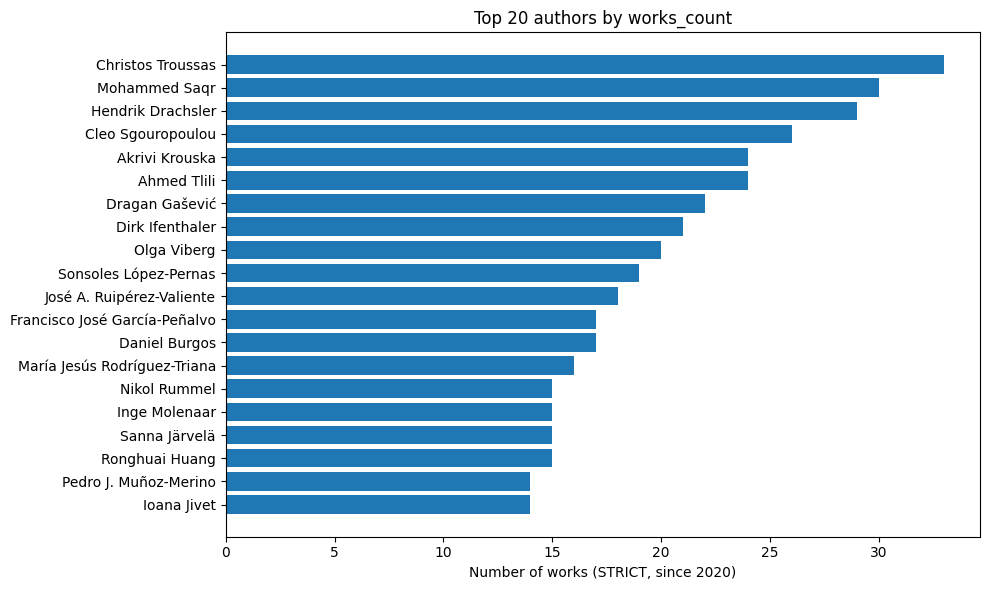

In [53]:

import matplotlib.pyplot as plt

# Sort by works_count and take top 20
top_authors = (
    authors_full
    .sort_values("works_count", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_authors["author_name"], top_authors["works_count"])
plt.gca().invert_yaxis()  # largest at top
plt.xlabel("Number of works (STRICT, since 2020)")
plt.title("Top 20 authors by works_count")
plt.tight_layout()
plt.show()


Number of key authors: 417
Number of edges among key authors: 1037
Nodes in largest component: 243


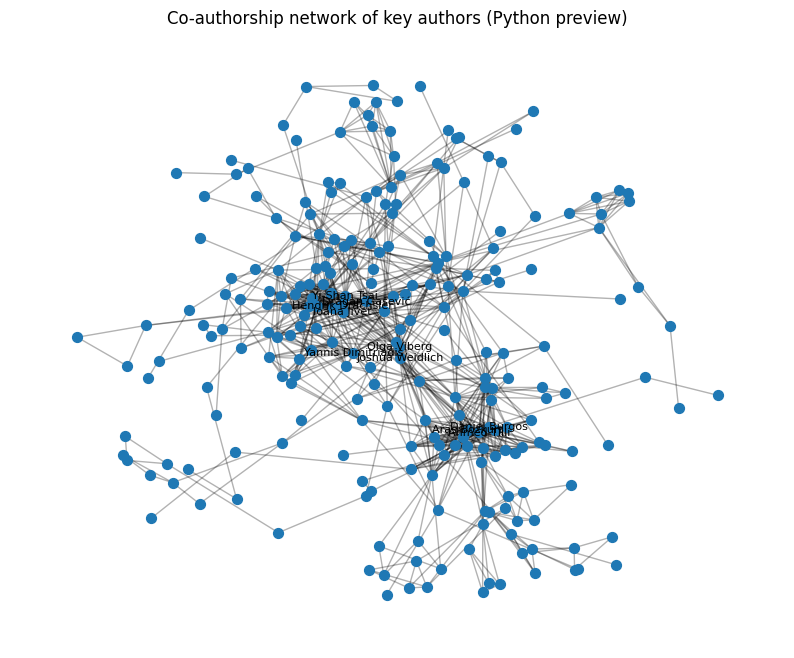

In [54]:
import networkx as nx
import matplotlib.pyplot as plt

# Choose a subset: authors with works_count >= 4 (for example)
key_authors = authors_full[authors_full["works_count"] >= 4]
key_ids = set(key_authors["author_id"])

# Filter edges to only those between key authors
edges_authors_key = edges_authors[
    edges_authors["from_author_id"].isin(key_ids) &
    edges_authors["to_author_id"].isin(key_ids)
]

print("Number of key authors:", len(key_authors))
print("Number of edges among key authors:", len(edges_authors_key))

# Build a graph in networkx
G = nx.Graph()
for _, row in edges_authors_key.iterrows():
    G.add_edge(row["from_author_id"], row["to_author_id"], weight=row["weight"])

# Map author_id back to name for labels
id_to_name = dict(zip(authors_full["author_id"], authors_full["author_name"]))

# Take the largest connected component to avoid lots of isolated nodes
if len(G) > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
else:
    G_sub = G

print("Nodes in largest component:", len(G_sub.nodes()))

# Build positions for plotting
pos = nx.spring_layout(G_sub, k=0.3, iterations=50)

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G_sub, pos, node_size=50)
nx.draw_networkx_edges(G_sub, pos, alpha=0.3)

# Only label a few largest nodes by degree or works_count (to avoid clutter)
degrees = dict(G_sub.degree())
# Take top 10 by degree
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:10]
labels = {n: id_to_name.get(n, "") for n in top_nodes}

nx.draw_networkx_labels(G_sub, pos, labels, font_size=8)

plt.axis("off")
plt.title("Co-authorship network of key authors (Python preview)")
plt.show()


In [55]:
import json

vos_data = {
    "nodes": [],
    "edges": []
}

# nodes
for _, row in nodes_authors.iterrows():
    vos_data["nodes"].append({
        "id": row["id"],
        "label": row["label"],
        "weight": float(row["works_count"])
    })

# edges
for _, row in edges_authors.iterrows():
    vos_data["edges"].append({
        "from": row["from_author_id"],
        "to": row["to_author_id"],
        "weight": float(row["weight"])
    })


In [56]:
with open("vos_authors.json", "w") as outfile:
    json.dump(vos_data, outfile, indent=2)


In [57]:
import os
print(os.listdir())


['1', '1_data_collection.ipynb', '2', '2_Scopus,SJR,OA_clean.ipynb', '3', '3_Network_VOS.ipynb', '4_features_clusters.ipynb', '5_core.ipynb', 'authors_full_strict_q1_q3.csv', 'institutions_full_strict_q1_q3.csv', 'openalex_works_strict_q1_q3.csv', 'vos_authors.json', 'vos_authors_coauthorship_edges.csv', 'vos_authors_nodes.csv', 'vos_concepts_cooccurrence_edges.csv', 'vos_concepts_nodes.csv', 'vos_institutions_collaboration_edges.csv', 'vos_institutions_nodes.csv']


In [58]:
print("Min weight:", edges_authors["weight"].min())
print("Any NaN weights?:", edges_authors["weight"].isna().sum())


Min weight: 1
Any NaN weights?: 0


# VOS SAVE FILES


In [59]:


print("=== STEP 1: Preparing AUTHOR NETWORK files for VOSviewer ===")

# 1) Rename edge columns to VOS format
edges_authors_vos = edges_authors.rename(columns={
    "from_author_id": "from",
    "to_author_id": "to",
    "weight": "strength"
}).copy()

# Ensure weight is float or int
edges_authors_vos["strength"] = pd.to_numeric(edges_authors_vos["strength"], errors="coerce").fillna(0)

# Do not allow negative values
edges_authors_vos["strength"] = edges_authors_vos["strength"].clip(lower=0)

# Save sparse network file: NO header
edges_authors_vos.to_csv(
    "authors_network_sparse.txt",
    sep="\t",
    header=False,
    index=False
)

print("Saved: authors_network_sparse.txt")
print(edges_authors_vos.head())

# -------------------------------------------------------------

print("\n=== STEP 2: Preparing AUTHOR MAP file for VOSviewer ===")

nodes_authors_map = authors_full[[
    "author_id",
    "author_name",
    "works_count"
]].rename(columns={
    "author_id": "id",
    "author_name": "label",
    "works_count": "weight"
}).copy()

nodes_authors_map["weight"] = pd.to_numeric(nodes_authors_map["weight"], errors="coerce").fillna(0)

# Save MAP file: WITH header
nodes_authors_map.to_csv(
    "authors_map.txt",
    sep="\t",
    index=False
)

print("Saved: authors_map.txt")
print(nodes_authors_map.head())

# -------------------------------------------------------------

# Print working directory so you know where files are
import os
print("\nFiles saved to directory:", os.getcwd())
print("Contained files:")
print(os.listdir())


=== STEP 1: Preparing AUTHOR NETWORK files for VOSviewer ===
Saved: authors_network_sparse.txt
                              from                                to  strength
0  https://openalex.org/A100168145  https://openalex.org/A1194086781         1
1  https://openalex.org/A100168145  https://openalex.org/A1201477854         1
2  https://openalex.org/A100168145  https://openalex.org/A1264139375         1
3  https://openalex.org/A100168145  https://openalex.org/A1536182517         1
4  https://openalex.org/A100168145  https://openalex.org/A1854755823         1

=== STEP 2: Preparing AUTHOR MAP file for VOSviewer ===
Saved: authors_map.txt
                                 id              label  weight
0   https://openalex.org/A100168145   Bruno Hochhegger       1
1  https://openalex.org/A1043128496      David Baneres       2
2   https://openalex.org/A105690434  Natalia Kucirkova       1
3  https://openalex.org/A1060563842   John Garofalakis       2
4  https://openalex.org/A1063351267 

In [60]:
nodes_con = pd.read_csv("vos_concepts_nodes.csv")
print(nodes_con.columns)

Index(['id', 'total_count', 'label'], dtype='object')


In [61]:


# Load your node data
nodes_con = pd.read_csv("vos_concepts_nodes.csv")

# Rename total_count → weight
nodes_con_vos = nodes_con.rename(columns={
    "total_count": "weight"
}).copy()

# Ensure weight is numeric
nodes_con_vos["weight"] = pd.to_numeric(nodes_con_vos["weight"], errors="coerce").fillna(0)

# Save as TAB file with header
nodes_con_vos.to_csv("concepts_map.txt", sep="\t", index=False)

print("DONE ✔️ Saved concepts_map.txt for VOSviewer")
print(nodes_con_vos.head())


DONE ✔️ Saved concepts_map.txt for VOSviewer
                             id  weight                         label
0  2019-20 coronavirus outbreak     146  2019-20 coronavirus outbreak
1           21st century skills      28           21st century skills
2            3D pose estimation       2            3D pose estimation
3                   3D printing       7                   3D printing
4                      3d model       1                      3d model


In [62]:
edges_con = pd.read_csv("vos_concepts_cooccurrence_edges.csv")

# rename columns for VOS
edges_con_vos = edges_con.rename(columns={
    "from_concept": "from",
    "to_concept": "to",
    "weight": "strength"
}).copy()

edges_con_vos["strength"] = pd.to_numeric(edges_con_vos["strength"], errors="coerce").fillna(0)
edges_con_vos["strength"] = edges_con_vos["strength"].clip(lower=0)

# Save as tab-separated without header
edges_con_vos.to_csv("concepts_network_sparse.txt", sep="\t", index=False, header=False)

print("DONE ✔️ Saved concepts_network_sparse.txt for VOSviewer")
print(edges_con_vos.head())


DONE ✔️ Saved concepts_network_sparse.txt for VOSviewer
                           from                       to  strength
0  2019-20 coronavirus outbreak            Academic year         1
1  2019-20 coronavirus outbreak                Acoustics         1
2  2019-20 coronavirus outbreak         Adaptation (eye)         1
3  2019-20 coronavirus outbreak              Archaeology         1
4  2019-20 coronavirus outbreak  Artificial intelligence         2


In [63]:


print("=== INSTITUTIONS → building VOSviewer files ===")

# 1) === MAP FILE (nodes) ===
# We will use institutions_full_strict_q1_q3.csv because it's your final institution table

# Load institutions full table
inst_full = pd.read_csv("institutions_full_strict_q1_q3.csv")
print("\n[INFO] institutions_full_strict_q1_q3.csv columns:")
print(inst_full.columns)

# Try to detect columns for id, label, weight
id_col = None
name_col = None
weight_col = None

for c in inst_full.columns:
    lc = c.lower()
    if id_col is None and ("institution_id" in lc or lc == "id"):
        id_col = c
    if name_col is None and ("institution_name" in lc or "name" == lc):
        name_col = c
    if weight_col is None and ("works_count" in lc or "n_papers" in lc or "publications" in lc):
        weight_col = c

# Fallbacks if something is still None
if id_col is None:
    raise ValueError("Could not find institution id column (e.g. 'institution_id') in inst_full.")
if name_col is None:
    # try something like 'label'
    for c in inst_full.columns:
        if "label" in c.lower():
            name_col = c
            break
    if name_col is None:
        raise ValueError("Could not find institution name column (e.g. 'institution_name') in inst_full.")
if weight_col is None:
    # if no works_count, use citations_sum as weight
    if "citations_sum" in inst_full.columns:
        weight_col = "citations_sum"
    else:
        # last resort: first numeric column after id/name
        numeric_cols = inst_full.select_dtypes(include="number").columns.tolist()
        if len(numeric_cols) == 0:
            raise ValueError("Could not find any numeric column to use as weight in inst_full.")
        weight_col = numeric_cols[0]

print(f"\n[INFO] Using columns for MAP file -> id: {id_col}, label: {name_col}, weight: {weight_col}")

nodes_inst_vos = inst_full[[id_col, name_col, weight_col]].copy()
nodes_inst_vos.columns = ["id", "label", "weight"]

nodes_inst_vos["weight"] = pd.to_numeric(nodes_inst_vos["weight"], errors="coerce").fillna(0)

nodes_inst_vos.to_csv("institutions_map.txt", sep="\t", index=False)
print("[OK] Saved institutions_map.txt")
print(nodes_inst_vos.head())

# 2) === NETWORK FILE (edges) ===
# Use vos_institutions_collaboration_edges.csv

edges_raw = pd.read_csv("vos_institutions_collaboration_edges.csv")
print("\n[INFO] vos_institutions_collaboration_edges.csv columns:")
print(edges_raw.columns)

from_col = None
to_col = None
weight_col_e = None

for c in edges_raw.columns:
    lc = c.lower()
    if from_col is None and ("from_institution" in lc or lc.startswith("from")):
        from_col = c
    if to_col is None and ("to_institution" in lc or lc.startswith("to")):
        to_col = c
    if weight_col_e is None and ("weight" in lc or "count" in lc or "strength" in lc):
        weight_col_e = c

if from_col is None or to_col is None or weight_col_e is None:
    raise ValueError(f"Could not detect from/to/weight columns in vos_institutions_collaboration_edges.csv. "
                     f"Detected: from={from_col}, to={to_col}, weight={weight_col_e}")

print(f"\n[INFO] Using columns for NETWORK file -> from: {from_col}, to: {to_col}, strength: {weight_col_e}")

edges_inst_vos = edges_raw[[from_col, to_col, weight_col_e]].copy()
edges_inst_vos.columns = ["from", "to", "strength"]

# Clean strength
edges_inst_vos["strength"] = pd.to_numeric(edges_inst_vos["strength"], errors="coerce").fillna(0)
edges_inst_vos["strength"] = edges_inst_vos["strength"].clip(lower=0)

edges_inst_vos.to_csv("institutions_network_sparse.txt", sep="\t", header=False, index=False)
print("[OK] Saved institutions_network_sparse.txt")
print(edges_inst_vos.head())

print("\n=== DONE ===")
print("Files created in:", os.getcwd())
print([f for f in os.listdir() if f.startswith('institutions_')])


=== INSTITUTIONS → building VOSviewer files ===

[INFO] institutions_full_strict_q1_q3.csv columns:
Index(['institution_id', 'institution_name', 'country_code', 'inst_type',
       'works_count', 'citations_sum', 'oa_share', 'collaboration_rate',
       'multi_country_rate', 'top_5_concepts', 'top_5_sources',
       'publications_by_year'],
      dtype='object')

[INFO] Using columns for MAP file -> id: institution_id, label: institution_name, weight: works_count
[OK] Saved institutions_map.txt
                                id                                   label  \
0         https://openalex.org/I-1                                     NaN   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   

   weight  
0       7  
1      

In [64]:
nodes_inst_vos = pd.read_csv("institutions_map.txt", sep="\t")

print("Total institution IDs:", len(nodes_inst_vos))
print("Unique institution IDs:", nodes_inst_vos["id"].nunique())

duplicates = nodes_inst_vos[nodes_inst_vos.duplicated("id", keep=False)]
print("Duplicate IDs found:")
print(duplicates.head(20))


Total institution IDs: 3676
Unique institution IDs: 3627
Duplicate IDs found:
                                   id  \
261    https://openalex.org/I12708293   
262    https://openalex.org/I12708293   
298  https://openalex.org/I1292875679   
299  https://openalex.org/I1292875679   
307  https://openalex.org/I1294671590   
308  https://openalex.org/I1294671590   
313   https://openalex.org/I129604602   
314   https://openalex.org/I129604602   
391  https://openalex.org/I1326498283   
392  https://openalex.org/I1326498283   
404  https://openalex.org/I1334415907   
405  https://openalex.org/I1334415907   
571   https://openalex.org/I148297040   
572   https://openalex.org/I148297040   
595   https://openalex.org/I151201029   
596   https://openalex.org/I151201029   
627   https://openalex.org/I154526488   
628   https://openalex.org/I154526488   
705   https://openalex.org/I162361429   
706   https://openalex.org/I162361429   

                                                 label  weig

In [65]:

nodes_inst_vos = pd.read_csv("institutions_map.txt", sep="\t")

# detect duplicates
duplicated_ids = nodes_inst_vos["id"].duplicated(keep=False)

# subset
dupes = nodes_inst_vos[duplicated_ids]

print("Duplicate count:", dupes["id"].nunique())

# Now assign unique suffixes
nodes_inst_vos["id"] = nodes_inst_vos["id"].astype(str)
nodes_inst_vos["id"] = nodes_inst_vos.groupby("id").cumcount().astype(str) + "_" + nodes_inst_vos["id"]

# Optionally: fix label too (to maintain mapping)
nodes_inst_vos["label"] = nodes_inst_vos["label"].astype(str)

# Re-save the corrected file
nodes_inst_vos.to_csv("institutions_map_FIXED.txt", sep="\t", index=False)

print("✔️ FIXED: Saved institutions_map_FIXED.txt with unique IDs")


Duplicate count: 49
✔️ FIXED: Saved institutions_map_FIXED.txt with unique IDs


In [66]:


print("=== REBUILDING INSTITUTION NETWORK FOR VOSVIEWER ===")

# 1) Load final institution table (entities)
inst_full = pd.read_csv("institutions_full_strict_q1_q3.csv")
print("[INFO] institutions_full_strict_q1_q3.csv columns:", list(inst_full.columns))

# --- NODES / MAP FILE ---

# Group by institution_id in case there are duplicates
nodes_inst = (
    inst_full
    .groupby("institution_id", as_index=False)
    .agg({
        "institution_name": "first",     # label
        "works_count": "sum"             # weight (you could also use citations_sum)
    })
)

# Rename to VOS columns
nodes_inst_vos = nodes_inst.rename(columns={
    "institution_id": "id",
    "institution_name": "label",
    "works_count": "weight"
}).copy()

# Ensure numeric weight
nodes_inst_vos["weight"] = pd.to_numeric(nodes_inst_vos["weight"], errors="coerce").fillna(0)

# Save map file (with header)
nodes_inst_vos.to_csv("inst_map_vos.txt", sep="\t", index=False)
print("[OK] Saved inst_map_vos.txt   (nodes / map)")
print(nodes_inst_vos.head())

# --- EDGES / NETWORK FILE ---

# Load collaboration edges we already computed
edges_raw = pd.read_csv("vos_institutions_collaboration_edges.csv")
print("[INFO] vos_institutions_collaboration_edges.csv columns:", list(edges_raw.columns))

# Rename to VOS format
edges_inst_vos = edges_raw.rename(columns={
    "from_institution_id": "from",
    "to_institution_id": "to",
    "weight": "strength"
}).copy()

# Keep only edges where both ends exist in node list
valid_ids = set(nodes_inst_vos["id"])
before = len(edges_inst_vos)
edges_inst_vos = edges_inst_vos[
    edges_inst_vos["from"].isin(valid_ids) &
    edges_inst_vos["to"].isin(valid_ids)
]
after = len(edges_inst_vos)
print(f"[INFO] Edges before filter: {before}, after filter: {after}")

# Clean strength
edges_inst_vos["strength"] = pd.to_numeric(edges_inst_vos["strength"], errors="coerce").fillna(0)
edges_inst_vos["strength"] = edges_inst_vos["strength"].clip(lower=0)

# Save network file (no header)
edges_inst_vos.to_csv("inst_network_vos.txt", sep="\t", header=False, index=False)
print("[OK] Saved inst_network_vos.txt   (edges / network)")
print(edges_inst_vos.head())

print("\nFiles created in:", os.getcwd())
print([f for f in os.listdir() if f.startswith('inst_')])


=== REBUILDING INSTITUTION NETWORK FOR VOSVIEWER ===
[INFO] institutions_full_strict_q1_q3.csv columns: ['institution_id', 'institution_name', 'country_code', 'inst_type', 'works_count', 'citations_sum', 'oa_share', 'collaboration_rate', 'multi_country_rate', 'top_5_concepts', 'top_5_sources', 'publications_by_year']
[OK] Saved inst_map_vos.txt   (nodes / map)
                                id                                   label  \
0         https://openalex.org/I-1                                    None   
1  https://openalex.org/I100005738                Brigham Young University   
2  https://openalex.org/I100066346                 University of Stuttgart   
3  https://openalex.org/I100205273  Universidad Técnica Particular de Loja   
4  https://openalex.org/I100445878                École Centrale de Nantes   

   weight  
0       7  
1       6  
2      10  
3       3  
4       3  
[INFO] vos_institutions_collaboration_edges.csv columns: ['from_institution_id', 'to_institution